In [1]:

import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df=pd.read_csv("/kaggle/input/datasets/taeefnajib/used-car-price-prediction-dataset/used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [4]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe(include="number")

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [7]:
df.describe(include="O")

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [8]:
pd.set_option('display.max_rows',1700)

In [9]:
lis=['brand','model','fuel_type','engine','transmission','ext_col','int_col','accident']

In [10]:
for i in lis:
    print(df[i].value_counts())
    print('----------------------------')

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
Lucid  

In [11]:
pd.reset_option('display.max_rows')

In [12]:
df.drop(columns=['clean_title'],axis=1,inplace=True)

In [13]:
def simplify_brand(x):
    economy = ['Ford','Toyota','Chevrolet','Nissan','Honda','Hyundai','Kia','Mazda']
    luxury = ['BMW','Mercedes-Benz','Audi','Lexus','Acura']
    exotic = ['Porsche','Ferrari','Lamborghini','Bentley','Rolls-Royce','McLaren']
    electric = ['Tesla','Rivian','Lucid']

    if x in economy:
        return 'Economy'
    elif x in luxury:
        return 'Luxury'
    elif x in exotic:
        return 'Exotic'
    


    elif x in electric:
        return 'Electric'
    else:
        return 'Other'



In [14]:
df['brand_group']=df['brand'].apply(simplify_brand)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,brand_group
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Economy
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Economy
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",Luxury
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Other
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Luxury


In [15]:
df['model_main'] = df['model'].apply(lambda x: x.split()[0])

In [16]:
top_models = df['model_main'].value_counts().head(30).index
df['model_main']=df["model_main"].apply(lambda x:x if x in top_models else 'Other')

In [17]:
df['model_main'].value_counts()

model_main
Other         2620
Rover          130
Model           87
911             80
Wrangler        73
F-150           64
Mustang         61
Corvette        61
AMG             60
1500            56
F-250           47
Silverado       46
E-Class         46
Escalade        45
Camaro          45
Suburban        38
X5              38
M3              37
Expedition      34
RX              33
Sierra          31
Grand           31
Cayenne         30
Yukon           30
Explorer        29
C-Class         28
Bronco          27
GX              26
Highlander      26
4Runner         25
Tundra          25
Name: count, dtype: int64

In [18]:
def simplify_fuel(x):
    if x == 'Gasoline':
        return 'Gasoline'
    elif 'Hybrid' in str(x):
        return 'Hybrid'
    elif x == 'Diesel':
        return 'Diesel'
    else:
        return 'Other'

df['fuel_type'] = df['fuel_type'].apply(simplify_fuel)

In [19]:
df['fuel_type'].value_counts()

fuel_type
Gasoline    3309
Other        356
Hybrid       228
Diesel       116
Name: count, dtype: int64

In [20]:
df['HP'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

In [21]:
df['Engine_Size'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)

In [22]:
df['Cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)

In [23]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
price             0
brand_group       0
model_main        0
HP              808
Engine_Size     377
Cylinders       945
dtype: int64

In [24]:
df['HP'].fillna(df['HP'].median(), inplace=True)
df['Engine_Size'].fillna(df['Engine_Size'].median(), inplace=True)
df['Cylinders'].fillna(df['Cylinders'].median(), inplace=True)

In [25]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
price             0
brand_group       0
model_main        0
HP                0
Engine_Size       0
Cylinders         0
dtype: int64

In [26]:
def simplify_trans(x):
    x = str(x)

    if 'A/T' in x or 'Automatic' in x:
        return 'Automatic'
    
    elif 'M/T' in x or 'Manual' in x:
        return 'Manual'
    
    elif 'CVT' in x:
        return 'CVT'
    
    else:
        return 'Other'

df['transmission'] = df['transmission'].apply(simplify_trans)

In [27]:
df['transmission'].value_counts()

transmission
Automatic    3148
Other         426
Manual        372
CVT            63
Name: count, dtype: int64

In [28]:
main_colors = ['Black','White','Gray','Silver','Blue','Red']

df['ext_col'] = df['ext_col'].apply(
    lambda x: x if x in main_colors else 'Other'
)

df['int_col'] = df['int_col'].apply(
    lambda x: x if x in main_colors else 'Other'
)

In [29]:
df['ext_col'].value_counts()

ext_col
Black     905
White     816
Other     808
Gray      496
Silver    374
Blue      349
Red       261
Name: count, dtype: int64

In [30]:
df['int_col'].value_counts()

int_col
Black     2025
Other     1214
Gray       472
White      127
Red        126
Blue        29
Silver      16
Name: count, dtype: int64

In [31]:
df['accident'] = df['accident'].map({
    'None reported':0,
    'At least 1 accident or damage reported':1
})

In [32]:
df['car_age'] = 2026 - df['model_year']

In [33]:
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,brand_group,model_main,HP,Engine_Size,Cylinders,car_age
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,1.0,"$10,300",Economy,Other,300.0,3.7,6.0,13
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,Automatic,Other,Gray,1.0,"$38,005",Economy,Other,310.0,3.8,6.0,5
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,0.0,"$54,598",Luxury,RX,310.0,3.5,6.0,4
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,0.0,"$15,500",Other,Other,354.0,3.5,6.0,11
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,Other,Black,0.0,"$34,999",Luxury,Other,310.0,2.0,6.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,Automatic,Other,Other,0.0,"$349,950",Exotic,Other,310.0,6.0,6.0,3
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Other,Black,Black,0.0,"$53,900",Luxury,Other,349.0,3.0,6.0,4
4006,Porsche,Taycan,2022,"2,116 mi.",Other,Electric,Automatic,Black,Black,0.0,"$90,998",Exotic,Other,310.0,3.5,6.0,4
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Automatic,Blue,Black,0.0,"$62,999",Economy,F-150,450.0,3.5,6.0,6


In [34]:
df.drop(columns=['brand','model','model_year','engine'],axis=1,inplace=True)
df

,milage,fuel_type,transmission,ext_col,int_col,accident,price,brand_group,model_main,HP,Engine_Size,Cylinders,car_age
0,"51,000 mi.",Other,Automatic,Black,Black,1.0,"$10,300",Economy,Other,300.0,3.7,6.0,13
1,"34,742 mi.",Gasoline,Automatic,Other,Gray,1.0,"$38,005",Economy,Other,310.0,3.8,6.0,5
2,"22,372 mi.",Gasoline,Automatic,Blue,Black,0.0,"$54,598",Luxury,RX,310.0,3.5,6.0,4
3,"88,900 mi.",Hybrid,Automatic,Black,Black,0.0,"$15,500",Other,Other,354.0,3.5,6.0,11
4,"9,835 mi.",Gasoline,Automatic,Other,Black,0.0,"$34,999",Luxury,Other,310.0,2.0,6.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,714 mi.,Gasoline,Automatic,Other,Other,0.0,"$349,950",Exotic,Other,310.0,6.0,6.0,3
4005,"10,900 mi.",Gasoline,Other,Black,Black,0.0,"$53,900",Luxury,Other,349.0,3.0,6.0,4
4006,"2,116 mi.",Other,Automatic,Black,Black,0.0,"$90,998",Exotic,Other,310.0,3.5,6.0,4
4007,"33,000 mi.",Gasoline,Automatic,Blue,Black,0.0,"$62,999",Economy,F-150,450.0,3.5,6.0,6


In [35]:
df['milage'] = df['milage'].str.replace(',', '').str.extract('(\d+)').astype(float)

In [36]:
df['price'] = df['price'].str.replace('$','', regex=False).str.replace(',','').astype(float)

In [37]:
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
df

,milage,fuel_type,transmission,ext_col,int_col,accident,price,brand_group,model_main,HP,Engine_Size,Cylinders,car_age
0,51000.0,Other,Automatic,Black,Black,1.0,10300.0,Economy,Other,300.0,3.7,6.0,13
1,34742.0,Gasoline,Automatic,Other,Gray,1.0,38005.0,Economy,Other,310.0,3.8,6.0,5
2,22372.0,Gasoline,Automatic,Blue,Black,0.0,54598.0,Luxury,RX,310.0,3.5,6.0,4
3,88900.0,Hybrid,Automatic,Black,Black,0.0,15500.0,Other,Other,354.0,3.5,6.0,11
4,9835.0,Gasoline,Automatic,Other,Black,0.0,34999.0,Luxury,Other,310.0,2.0,6.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,714.0,Gasoline,Automatic,Other,Other,0.0,349950.0,Exotic,Other,310.0,6.0,6.0,3
4005,10900.0,Gasoline,Other,Black,Black,0.0,53900.0,Luxury,Other,349.0,3.0,6.0,4
4006,2116.0,Other,Automatic,Black,Black,0.0,90998.0,Exotic,Other,310.0,3.5,6.0,4
4007,33000.0,Gasoline,Automatic,Blue,Black,0.0,62999.0,Economy,F-150,450.0,3.5,6.0,6


# Visulization

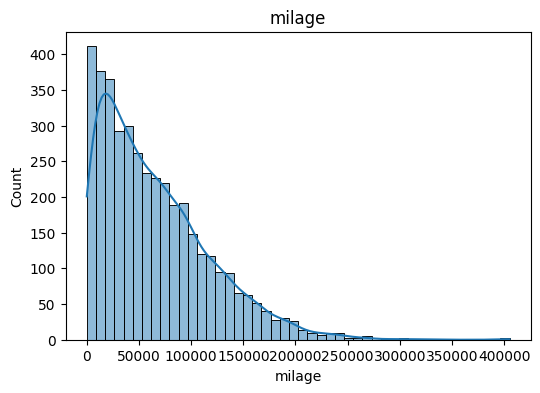

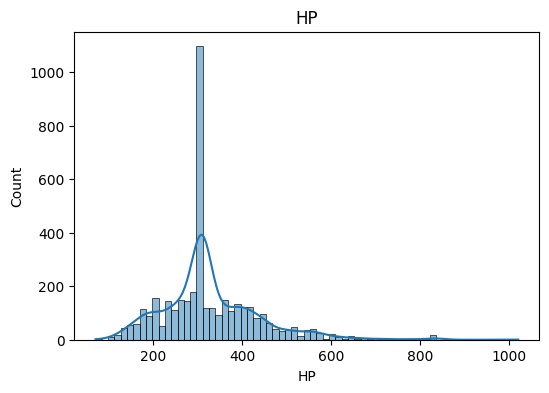

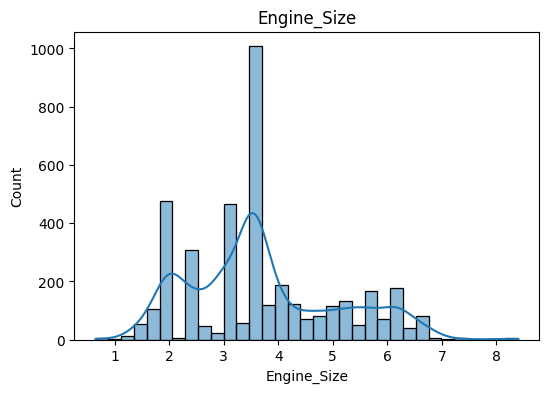

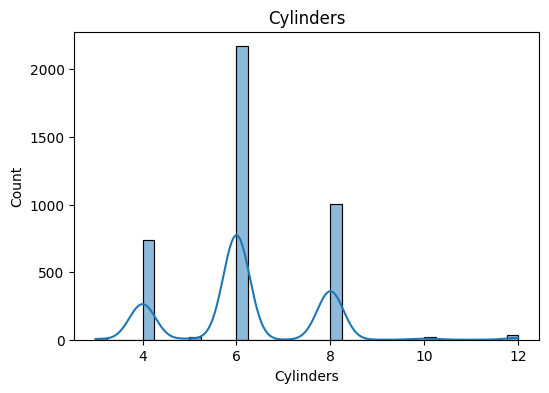

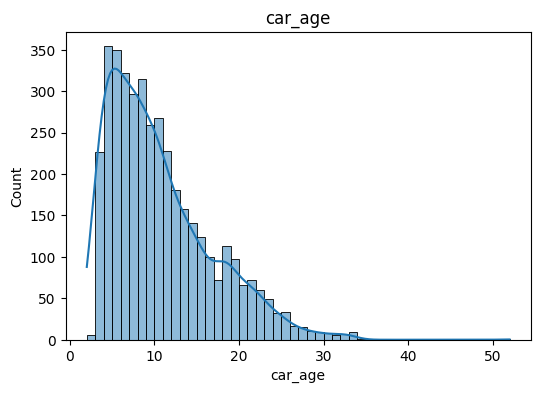

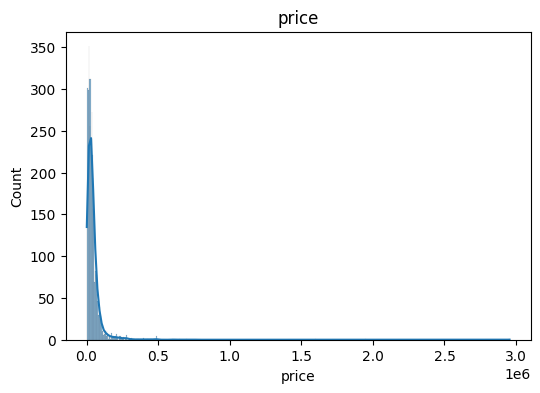

In [38]:
num_cols = ['milage','HP','Engine_Size','Cylinders','car_age','price']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [39]:
print(df[['milage','HP','Engine_Size','Cylinders','car_age','price']].skew())

milage          1.159975
HP              1.170481
Engine_Size     0.551600
Cylinders       0.477246
car_age         1.089231
price          19.513551
dtype: float64


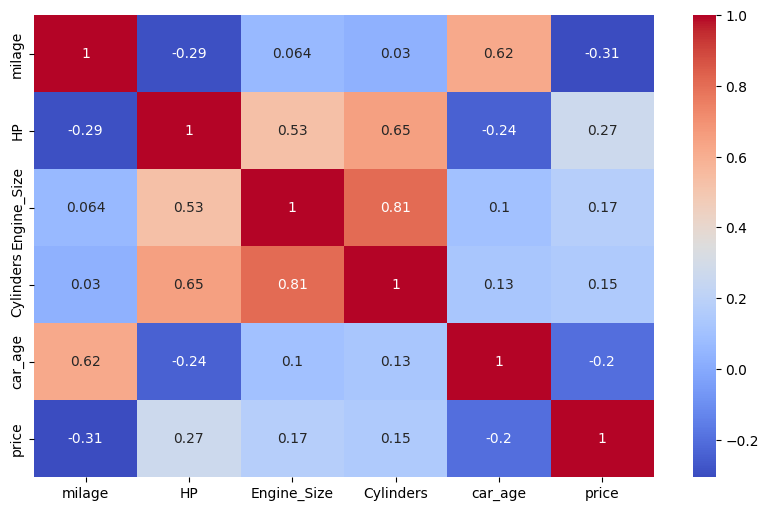

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# Encoding

In [41]:
cat_cols = ['fuel_type','transmission','ext_col','int_col','brand_group','model_main']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df

,milage,accident,price,HP,Engine_Size,Cylinders,car_age,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Other,...,model_main_Other,model_main_RX,model_main_Rover,model_main_Sierra,model_main_Silverado,model_main_Suburban,model_main_Tundra,model_main_Wrangler,model_main_X5,model_main_Yukon
0,51000.0,1.0,10300.0,300.0,3.7,6.0,13,False,False,True,...,True,False,False,False,False,False,False,False,False,False
1,34742.0,1.0,38005.0,310.0,3.8,6.0,5,True,False,False,...,True,False,False,False,False,False,False,False,False,False
2,22372.0,0.0,54598.0,310.0,3.5,6.0,4,True,False,False,...,False,True,False,False,False,False,False,False,False,False
3,88900.0,0.0,15500.0,354.0,3.5,6.0,11,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,9835.0,0.0,34999.0,310.0,2.0,6.0,5,True,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,714.0,0.0,349950.0,310.0,6.0,6.0,3,True,False,False,...,True,False,False,False,False,False,False,False,False,False
4005,10900.0,0.0,53900.0,349.0,3.0,6.0,4,True,False,False,...,True,False,False,False,False,False,False,False,False,False
4006,2116.0,0.0,90998.0,310.0,3.5,6.0,4,False,False,True,...,True,False,False,False,False,False,False,False,False,False
4007,33000.0,0.0,62999.0,450.0,3.5,6.0,6,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [42]:
df['milage'] = df['milage'].clip(
    df['milage'].quantile(0.01),
    df['milage'].quantile(0.99)
)

df['HP'] = df['HP'].clip(
    df['HP'].quantile(0.01),
    df['HP'].quantile(0.99)
)

In [43]:
df['price'] = np.log1p(df['price'])

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers

,milage,accident,price,HP,Engine_Size,Cylinders,car_age,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Other,...,model_main_Other,model_main_RX,model_main_Rover,model_main_Sierra,model_main_Silverado,model_main_Suburban,model_main_Tundra,model_main_Wrangler,model_main_X5,model_main_Yukon
16,1685.00,0.0,12.429220,310.0,2.0,6.0,5,True,False,False,...,True,False,False,False,False,False,False,False,False,False
76,634.68,0.0,12.793837,310.0,5.2,6.0,3,True,False,False,...,True,False,False,False,False,False,False,False,False,False
89,210703.00,0.0,7.741099,165.0,2.5,4.0,22,True,False,False,...,True,False,False,False,False,False,False,False,False,False
93,2165.00,0.0,12.542370,310.0,5.2,6.0,5,True,False,False,...,True,False,False,False,False,False,False,False,False,False
180,4529.00,0.0,12.942042,310.0,3.8,6.0,8,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,5072.00,0.0,12.542370,310.0,4.0,6.0,6,True,False,False,...,True,False,False,False,False,False,False,False,False,False
3816,3420.00,0.0,12.899097,310.0,6.7,6.0,4,True,False,False,...,True,False,False,False,False,False,False,False,False,False
3907,222428.00,1.0,7.824446,200.0,3.0,6.0,26,True,False,False,...,True,False,False,False,False,False,False,False,False,False
3922,94200.00,1.0,7.824446,310.0,3.5,6.0,33,False,False,True,...,True,False,False,False,False,False,False,False,False,False


In [44]:
df = df[(df['price'] >= lower) & (df['price'] <= upper)]

In [45]:
X = df.drop('price', axis=1)
y = df['price']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [47]:
num_cols = ['milage','HP','Engine_Size','Cylinders','car_age']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)


In [51]:
pred1=model.predict(X_train)
print("R2 Score:", r2_score(y_train, pred1))
print("MAE:", mean_absolute_error(y_train, pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, pred1)))

R2 Score: 0.8289886538197552
MAE: 0.23241483022540377
RMSE: 0.3259182802190076


In [53]:
pred2=model.predict(X_test)
print("R2 Score:", r2_score(y_test, pred2))
print("MAE:", mean_absolute_error(y_test, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred2)))

R2 Score: 0.8277580245310672
MAE: 0.23885006064830164
RMSE: 0.32878614680861484
